
# Exploratory Data Analysis (EDA) - Stack Overflow Career Classification

Notebook ini digunakan untuk melakukan proses **Exploratory Data Analysis (EDA)** dan visualisasi data
pada dataset Stack Overflow Survey hasil cleaning sebelum masuk ke tahap modeling machine learning.

## Tujuan EDA
- Memahami distribusi target variable (`career_label`)
- Menganalisis popularitas skills dan tools
- Mengecek distribusi fitur numerik dan outlier
- Mengecek korelasi antar fitur numerik
- Mensimulasikan efek balancing menggunakan SMOTE

---
Dataset: `dataset_so_clean.csv`


## 1. Setup Library & Load Dataset

In [2]:

# ============================================================
# IMPORT LIBRARY
# ============================================================

import pandas as pd
import numpy as np

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Text Processing
from collections import Counter
from wordcloud import WordCloud

# Ignore warning
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# TEMA VISUALISASI
# ============================================================

sns.set_theme(
    style="whitegrid",
    palette="deep"
)

# ============================================================
# LOAD DATASET
# ============================================================

df = pd.read_csv('dataset_so_clean.csv')

print("Shape Dataset :", df.shape)

# Preview dataset
df.head()


Shape Dataset : (25792, 6)


,all_skills,tools,databases,years_code,education_level,career_label
0,amazon web services (aws);bash/shell (all shel...,android studio;notepad++;visual studio;visual ...,cloud firestore;postgresql,14.0,2.0,Mobile App Developer
1,amazon web services (aws);datadog;docker;homeb...,intellij idea;pycharm;visual studio code;xcode,dynamodb;mongodb,10.0,3.0,Backend Developer
2,dart;datadog;firebase;html/css;javascript;next...,visual studio code,mongodb;mysql;postgresql,12.0,2.0,Frontend Developer
3,amazon web services (aws);google cloud;java;ko...,NaN,NaN,5.0,2.0,Backend Developer
4,amazon web services (aws);google cloud;java;mi...,intellij idea;visual studio code,NaN,20.0,2.0,Backend Developer


## 2. Quick Dataset Overview

In [3]:

# ============================================================
# INFORMASI DATASET
# ============================================================

df.info()

# ============================================================
# MISSING VALUES
# ============================================================

print("\nMissing Values:")
print(df.isnull().sum())

# ============================================================
# STATISTIK DESKRIPTIF
# ============================================================

df.describe(include='all')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25792 entries, 0 to 25791
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   all_skills       25792 non-null  object 
 1   tools            21100 non-null  object 
 2   databases        21354 non-null  object 
 3   years_code       25792 non-null  float64
 4   education_level  25792 non-null  float64
 5   career_label     25792 non-null  object 
dtypes: float64(2), object(4)
memory usage: 1.2+ MB

Missing Values:
all_skills            0
tools              4692
databases          4438
years_code            0
education_level       0
career_label          0
dtype: int64


,all_skills,tools,databases,years_code,education_level,career_label
count,25792,21100,21354,25792.000000,25792.000000,25792
unique,24450,6555,5915,NaN,NaN,18
top,python,visual studio code,postgresql,NaN,NaN,Backend Developer
freq,36,1583,1024,NaN,NaN,9300
mean,NaN,NaN,NaN,17.592936,2.143339,NaN
std,NaN,NaN,NaN,11.177527,0.891307,NaN
min,NaN,NaN,NaN,1.000000,0.000000,NaN
25%,NaN,NaN,NaN,9.000000,2.000000,NaN
50%,NaN,NaN,NaN,15.000000,2.000000,NaN
75%,NaN,NaN,NaN,25.000000,2.000000,NaN


## 3. Analisis Distribusi Target Variable (`career_label`)

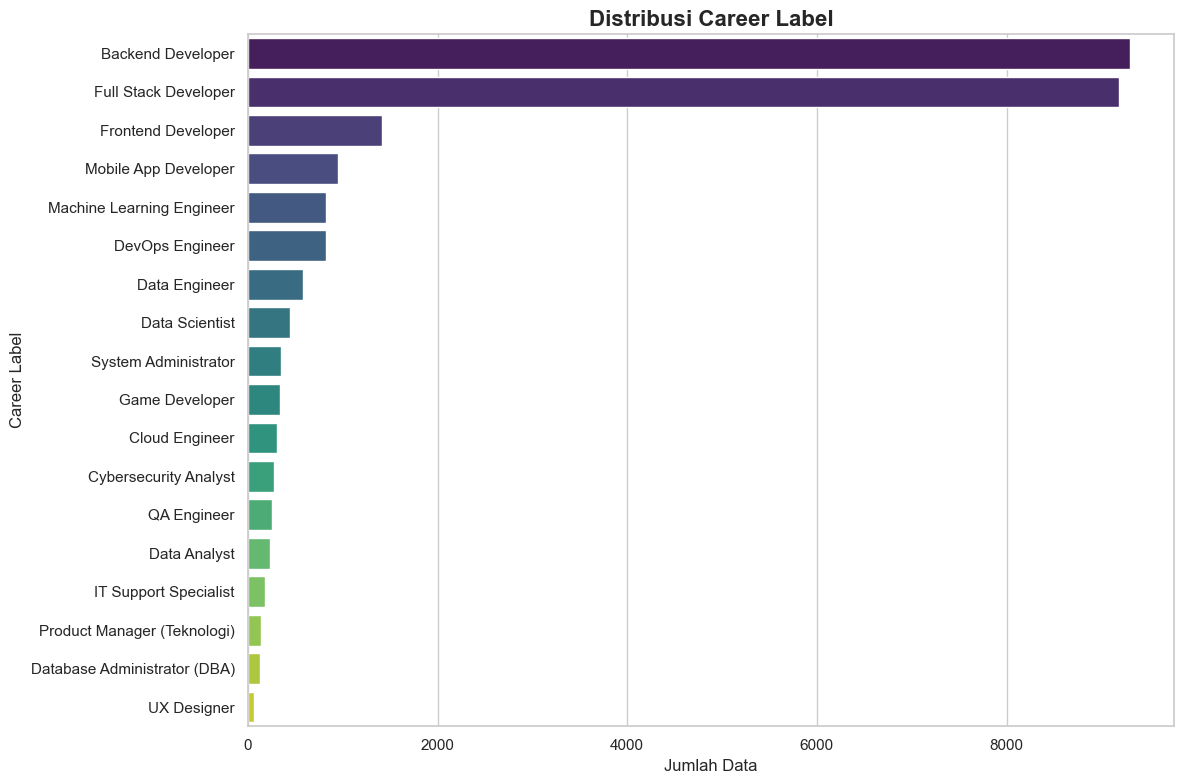

In [4]:

# ============================================================
# DISTRIBUSI TARGET VARIABLE
# ============================================================

career_counts = (
    df['career_label']
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 8))

sns.barplot(
    x=career_counts.values,
    y=career_counts.index,
    palette='viridis'
)

plt.title(
    'Distribusi Career Label',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Jumlah Data')
plt.ylabel('Career Label')

plt.tight_layout()
plt.show()


## 4. Analisis Fitur Teks / Skills & Tools

In [5]:

# ============================================================
# FUNGSI EKSTRAKSI TOP KEYWORDS
# ============================================================

def get_top_keywords(column_name, top_n=15):

    # Menggabungkan seluruh isi kolom menjadi satu string
    text_data = " ".join(
        df[column_name]
        .dropna()
        .astype(str)
    )

    keywords = []

    # Split berdasarkan koma
    for item in text_data.split(","):

        cleaned = item.strip().lower()

        if cleaned != "":
            keywords.append(cleaned)

    # Menghitung frekuensi kata
    keyword_freq = Counter(keywords)

    # Mengambil top keyword
    top_keywords = keyword_freq.most_common(top_n)

    return pd.DataFrame(
        top_keywords,
        columns=['Keyword', 'Frequency']
    )


### Top 15 Skill Paling Populer

In [ ]:

# ============================================================
# TOP 15 SKILLS
# ============================================================

top_skills = get_top_keywords(
    column_name='all_skills',
    top_n=15
)

display(top_skills)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_skills,
    x='Frequency',
    y='Keyword',
    palette='magma'
)

plt.title(
    'Top 15 Skills Paling Populer',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Frekuensi')
plt.ylabel('Skill')

plt.tight_layout()
plt.show()


,Keyword,Frequency
0,amazon web services (aws);bash/shell (all shel...,1


KeyboardInterrupt: 

### Word Cloud Skills

In [ ]:

# ============================================================
# WORD CLOUD SKILLS
# ============================================================

all_skills_text = " ".join(
    df['all_skills']
    .dropna()
    .astype(str)
)

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    colormap='viridis'
).generate(all_skills_text)

plt.figure(figsize=(15, 7))

plt.imshow(wordcloud, interpolation='bilinear')

plt.axis('off')

plt.title(
    'Word Cloud Skills',
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout()
plt.show()


## 5. Analisis Fitur Numerik

### Distribusi Fitur Numerik (`YearsCode`)

In [ ]:

# ============================================================
# HISTOGRAM & DENSITY PLOT
# ============================================================

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x='YearsCode',
    bins=30,
    kde=True,
    color='steelblue'
)

plt.title(
    'Distribusi YearsCode',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Years of Coding Experience')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


### Deteksi Outlier Menggunakan Boxplot

In [ ]:

# ============================================================
# BOXPLOT OUTLIER
# ============================================================

numeric_cols = df.select_dtypes(
    include=['int64', 'float64']
).columns

for col in numeric_cols:

    plt.figure(figsize=(10, 3))

    sns.boxplot(
        x=df[col],
        color='tomato'
    )

    plt.title(
        f'Boxplot - {col}',
        fontsize=14,
        fontweight='bold'
    )

    plt.tight_layout()
    plt.show()


## 6. Analisis Korelasi Antar Fitur

In [ ]:

# ============================================================
# HEATMAP KORELASI
# ============================================================

numeric_df = df.select_dtypes(
    include=['int64', 'float64']
)

corr_matrix = numeric_df.corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title(
    'Correlation Matrix',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.show()


## 7. Visualisasi Efek Balancing (Sebelum vs Sesudah SMOTE)

In [ ]:

# ============================================================
# DISTRIBUSI SEBELUM SMOTE
# ============================================================

before_smote = df['career_label'].value_counts()

# ============================================================
# SIMULASI SESUDAH SMOTE
# ============================================================

max_count = before_smote.max()

after_smote = pd.Series(
    [max_count] * len(before_smote),
    index=before_smote.index
)

# ============================================================
# SIDE-BY-SIDE BAR CHART
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(18, 8)
)

# Sebelum SMOTE
sns.barplot(
    x=before_smote.values,
    y=before_smote.index,
    palette='rocket',
    ax=axes[0]
)

axes[0].set_title(
    'Distribusi Sebelum SMOTE',
    fontsize=14,
    fontweight='bold'
)

axes[0].set_xlabel('Jumlah Data')
axes[0].set_ylabel('Career Label')

# Sesudah SMOTE
sns.barplot(
    x=after_smote.values,
    y=after_smote.index,
    palette='crest',
    ax=axes[1]
)

axes[1].set_title(
    'Distribusi Sesudah SMOTE',
    fontsize=14,
    fontweight='bold'
)

axes[1].set_xlabel('Jumlah Data')
axes[1].set_ylabel('Career Label')

plt.tight_layout()
plt.show()



## 8. Kesimpulan EDA

Dari hasil Exploratory Data Analysis (EDA), dapat diperoleh beberapa insight penting:

- Distribusi kelas masih bersifat imbalanced sehingga SMOTE diperlukan.
- Skill tertentu mendominasi dataset Stack Overflow Survey.
- Distribusi numerik membantu mendeteksi outlier dan skewness.
- Heatmap korelasi membantu mengecek potensi multikolinearitas.

Tahap berikutnya:
- Feature Engineering
- TF-IDF / Vectorization
- SMOTE
- Model Training
- Hyperparameter Tuning
- Evaluation
